# Home Assignment 2: Linear Kalman Filter for Smartphone Sensors


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

## 1. Load data

- **Accelerometer CSV**: time (s), gFx, gFy, gFz (in g-units). Multiply by 9.81 for m/s².
- **GPS CSV**: Separate file with Time, Latitude, Longitude. Distance from start is computed with Haversine.

In [2]:
# Load accelerometer data
acc_file = "accelerometer_2026-03-11_11.06.55.csv"
df_acc = pd.read_csv(acc_file, comment='#')
df_acc.columns = df_acc.columns.str.strip()
# Ensure numeric
for c in ['time', 'gFx', 'gFy', 'gFz']:
    df_acc[c] = pd.to_numeric(df_acc[c], errors='coerce')
df_acc = df_acc.dropna(subset=['time', 'gFx', 'gFy', 'gFz'])
t_acc = df_acc['time'].values
# Convert g to m/s^2
g = 9.81
ax_g = df_acc['gFx'].values * g
ay_g = df_acc['gFy'].values * g
az_g = df_acc['gFz'].values * g
print(f"Accelerometer: {len(t_acc)} samples, t in [{t_acc.min():.2f}, {t_acc.max():.2f}] s")

Accelerometer: 1525 samples, t in [0.00, 15.59] s


In [3]:
# Load GPS from separate CSV
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in m
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

gps_file = "gps_20260311_114127.csv"
df_gps = pd.read_csv(gps_file)
df_gps.columns = df_gps.columns.str.strip()
# Parse time to seconds since first sample
times = pd.to_datetime(df_gps["Time"], errors="coerce")
t_gps_sec = (times - times.iloc[0]).dt.total_seconds().values
lat = pd.to_numeric(df_gps["Latitude"], errors="coerce").values
lon = pd.to_numeric(df_gps["Longitude"], errors="coerce").values
valid = ~(np.isnan(t_gps_sec) | np.isnan(lat) | np.isnan(lon))
t_gps_sec = t_gps_sec[valid]
lat = lat[valid]
lon = lon[valid]
# Cumulative distance from start (Haversine)
z_gps = np.zeros(len(lat))
for i in range(1, len(lat)):
    z_gps[i] = z_gps[i-1] + haversine_m(lat[i-1], lon[i-1], lat[i], lon[i])
# Align GPS time with accelerometer: assume both recordings start together (t=0)
t_gps_abs = t_acc[0] + t_gps_sec
# Optional: use Accuracy column for measurement noise (if present, in m)
if "Accuracy" in df_gps.columns:
    acc_vals = pd.to_numeric(df_gps["Accuracy"], errors="coerce").values[valid]
    std_meas = float(np.nanmean(acc_vals))
    std_meas = max(std_meas, 3.0)
else:
    std_meas = 5.0
has_gps = True
print(f"GPS: {len(z_gps)} points, distance from start = {z_gps[-1]:.1f} m, std_meas = {std_meas:.1f} m")

GPS: 21 points, distance from start = 17.5 m, std_meas = 19.9 m


## 2. Noise parameters (Hint)

- **std_acc (process noise)**: Std of accelerometer when phone is still or moving uniformly.
- **std_meas (measurement noise)**: GPS accuracy (e.g. 3–5 m) or std when standing still.

In [4]:
# Stationary segment: first 1 s (phone at rest)
t0, t1 = t_acc[0], t_acc[0] + 1.0
mask_still = (t_acc >= t0) & (t_acc <= t1)
ax_s = ax_g[mask_still]
ay_s = ay_g[mask_still]
az_s = az_g[mask_still]
# Linear acc = remove gravity (bias when still)
mean_ax, mean_ay, mean_az = np.mean(ax_s), np.mean(ay_s), np.mean(az_s)
lin_ax = ax_g - mean_ax
lin_ay = ay_g - mean_ay
lin_az = az_g - mean_az
# Process noise: std of linear acceleration when still
std_acc = np.std(np.sqrt(lin_ax[mask_still]**2 + lin_ay[mask_still]**2 + lin_az[mask_still]**2))
std_acc = max(std_acc, 0.1)  # lower bound
# std_meas was set from GPS file (Accuracy column); otherwise use 3–5 m
print(f"std_acc (process) = {std_acc:.4f} m/s²,  std_meas (GPS) = {std_meas:.2f} m")

std_acc (process) = 0.1063 m/s²,  std_meas (GPS) = 19.86 m


In [5]:
# Direction of motion: axis with largest variance of linear acc (middle 50% of trip = movement)
n = len(t_acc)
mid_start, mid_end = n // 4, 3 * n // 4
vx = np.var(lin_ax[mid_start:mid_end])
vy = np.var(lin_ay[mid_start:mid_end])
vz = np.var(lin_az[mid_start:mid_end])
idx_max = np.argmax([vx, vy, vz])
dir_motion = np.array([1.0 if i == idx_max else 0.0 for i in range(3)])
# Scalar acceleration along motion (control input u)
u_acc = lin_ax * dir_motion[0] + lin_ay * dir_motion[1] + lin_az * dir_motion[2]

## 3. Linear Kalman Filter

State: $\mathbf{x} = [p, v]^T$ (position, velocity).  
Motion: $p_{k+1} = p_k + v_k \Delta t + \frac{1}{2} u_k \Delta t^2$, $v_{k+1} = v_k + u_k \Delta t$.  
Measurement: $z = p$ (GPS distance from start).

In [6]:
# Kalman filter: state x = [position, velocity]
# Predict: x_pred = F @ x + B @ u,  P_pred = F @ P @ F.T + Q
# Update (when GPS available): K = P_pred @ H.T @ inv(H@P_pred@H.T + R), x = x_pred + K*(z - H@x_pred), P = (I - K@H)@P_pred

n_acc = len(t_acc)
dt_arr = np.diff(t_acc)
dt_arr = np.concatenate([dt_arr, [dt_arr[-1]]])  # same length as t_acc

# State: [p, v]
x = np.array([0.0, 0.0])
P = np.diag([1.0, 1.0])
H = np.array([[1.0, 0.0]])
R = np.array([[std_meas**2]])
# Q will be set per step using dt

pos_kf = np.zeros(n_acc)
pos_kf[0] = 0.0
gps_idx = 0
for k in range(1, n_acc):
    dt = dt_arr[k]
    F = np.array([[1.0, dt], [0.0, 1.0]])
    B = np.array([[0.5 * dt**2], [dt]])
    Q = np.diag([(0.5 * dt**2)**2 * std_acc**2, dt**2 * std_acc**2])
    # Predict
    u = u_acc[k]
    x = F @ x + (B.flatten() * u)
    P = F @ P @ F.T + Q
    # Update with GPS when we pass the next GPS timestamp
    if gps_idx < len(t_gps_abs) and t_acc[k] >= t_gps_abs[gps_idx]:
        z = z_gps[gps_idx]
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        y = z - H @ x
        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P
        gps_idx += 1
    pos_kf[k] = x[0]
print("KF done.")

KF done.


## 4. Result: Measured (GPS) vs Predicted (KF) distance

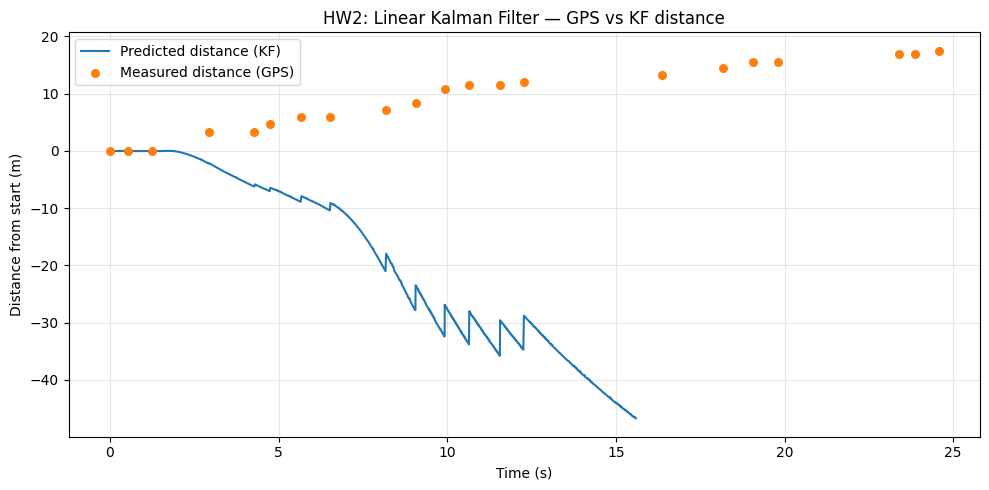

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(t_acc - t_acc[0], pos_kf, label='Predicted distance (KF)', color='C0')
plt.scatter(t_gps_abs - t_acc[0], z_gps, label='Measured distance (GPS)', color='C1', s=30, zorder=5)
plt.xlabel('Time (s)')
plt.ylabel('Distance from start (m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('HW2: Linear Kalman Filter — GPS vs KF distance')
plt.tight_layout()
plt.show()